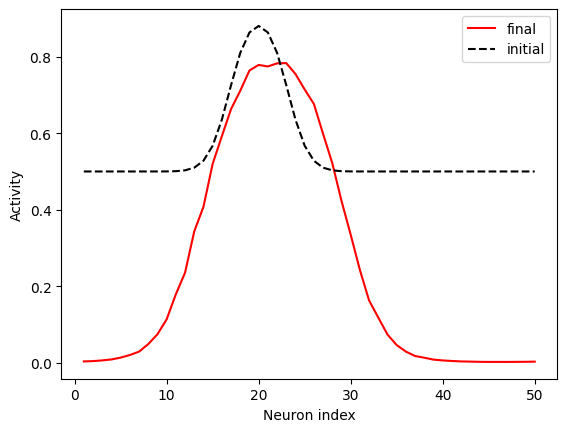

In [2]:
import numpy as np
from scipy.integrate import solve_ivp, quad_vec
from scipy.linalg import expm
import matplotlib.pyplot as plt

# %% parameters and connectivity
N = 50
tau = 0.01
J_E, J_I = 10, -9
I_ext = np.ones(N)

dt = 0.01
T_total = 1.0
tspan = np.arange(0, T_total + dt, dt)

phi = lambda x: (1 + np.tanh(x)) / 2
dphi = lambda x: 0.5 * (1 - np.tanh(x) ** 2)

theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
W = J_I + J_E * np.cos(theta[:, None] - theta[None, :])

# symmetric noise on the connectivity
rng = np.random.default_rng()
noise = 0.5 * rng.standard_normal((N, N))
W = W + (noise + noise.T) / 2

# %% find the stable bump
def ring_model(t, h, W, tau, I_ext):
    return (-h + (W @ phi(h)) / N + I_ext) / tau


bump_center = 20
sigma = N / 20
idx = np.arange(1, N + 1)
x0 = np.exp(-((idx - bump_center) ** 2) / (2 * sigma ** 2))

sol = solve_ivp(ring_model, [0, T_total], x0, t_eval=tspan,
                 args=(W, tau, I_ext), method="RK45", rtol=1e-8, atol=1e-10)
x_stable = sol.y[:, -1]

plt.figure()
plt.plot(idx, phi(x_stable), "r", label="final")
plt.plot(idx, phi(x0), "k--", label="initial")
plt.xlabel("Neuron index"); plt.ylabel("Activity"); plt.legend()
plt.show()

# %% linearize about the stable bump

D_phi = np.diag(dphi(x_stable))
A = -np.eye(N) + (W @ D_phi) / N

# %% minimum control energy

def control_energy(A, B, x0, xf, T, L=1000):
    """Minimum-energy input driving x0 -> xf over horizon T. Returns E, Wc, u_t, t_vec."""
    Phi = xf - expm(A * T) @ x0

    def gramian_integrand(t):
        M = expm(A * t) @ B
        return M @ M.T

    Wc, _ = quad_vec(gramian_integrand, 0, T, epsabs=1e-12, epsrel=1e-10)
    WcI = np.linalg.inv(Wc)
    E = Phi @ (WcI @ Phi)

    t_vec = np.linspace(0, T, L)
    WcI_Phi = WcI @ Phi
    u_t = np.array([B.T @ expm(A.T * (T - t)) @ WcI_Phi for t in t_vec]).T

    return E, Wc, u_t, t_vec

minimum control energy to shift bump by 5 nodes: 35.6006


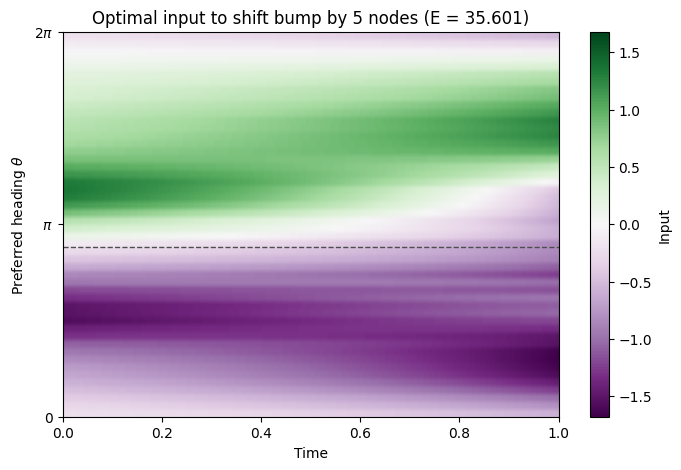

In [3]:
# %% shift the bump by 5 nodes

B = np.eye(N)
shift_amt = 5
x_target = np.roll(x_stable, shift_amt)

dx0 = np.zeros(N)
dxf = x_target - x_stable
T_horizon = 1.0

E, Wc, u_t, t_vec = control_energy(A, B, dx0, dxf, T_horizon)
print(f"minimum control energy to shift bump by {shift_amt} nodes: {E:.4f}")

# %% heatmap of the optimal input, heading angle x time

theta_bump = theta[np.argmax(x_stable)]
m = np.max(np.abs(u_t))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(u_t, extent=[t_vec[0], t_vec[-1], 0, 2 * np.pi], origin="lower",
               aspect="auto", cmap="PRGn", vmin=-m, vmax=m)
ax.axhline(theta_bump, ls="--", color="0.3", lw=1)
ax.set_xlabel("Time")
ax.set_ylabel(r"Preferred heading $\theta$")
ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
ax.set_title(f"Optimal input to shift bump by {shift_amt} nodes (E = {E:.3f})")
fig.colorbar(im, ax=ax, label="Input")
plt.savefig("ring_optimal_input.pdf", bbox_inches="tight", dpi=300)
plt.show()